# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [ ]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from NM_TinyRNN.code.models import training_fast as speedrun
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import nested_cv_io as save_data
from NM_TinyRNN.code.models import nested_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

In [11]:

# let's test some code!
test_data_path = DATA_PATH / "bayes_optimal"
test_save_path  = './NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(speedrun)
reload(rnns)
# we use a trainer with ensemble model training across hyperparameters
trainer = speedrun.TrainerGPU(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1e-7],
                        energy_lambdas = [1e-1,0.01],
                        hebbian_lambdas = [1.0,0.1,0.01],
                        covariance_lambdas = [10.0,1.0,0.1])
model = rnns.TinyRNN(rnn_type = 'monoGRU',nonlinearity = 'relu', hidden_size = 2,
                     input_encoding='onehot',input_forced_choice = False)
dataset = ds.AB_Dataset(test_data_path, sequence_length = 64)
## You may test the trainer class to fit a single model:

final_state_dict, config, loss_dict = trainer.fit(model, dataset)


Sequence length 64 excludes 13.3% of trials
Parallelizing 180 models on cpu


 14%|█▍        | 1412/10000 [04:14<25:44,  5.56it/s]

Search complete. Best model index: 120. Val. loss: 0.06504636257886887


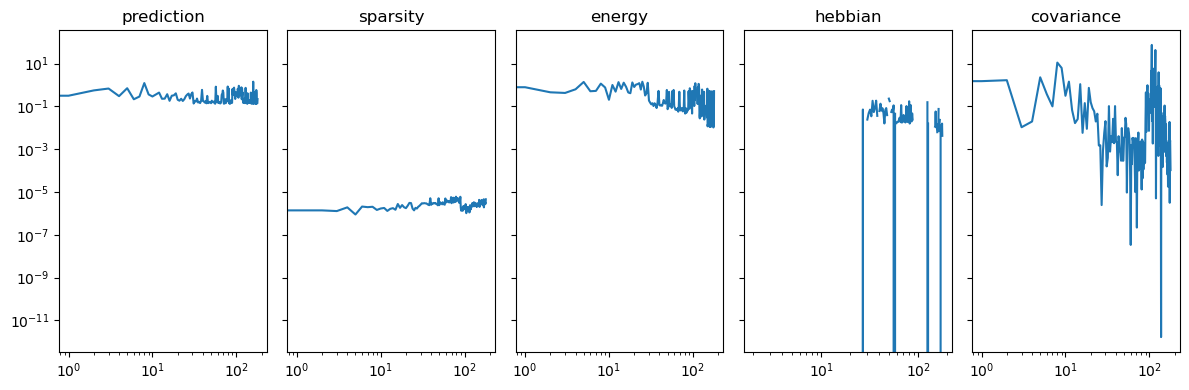

In [5]:
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].loglog(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

In [ ]:
dataset

[outer 1/10]  outer eval: 4 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu


  0%|          | 0/10000 [00:00<?, ?it/s]

IndexError: index 39 is out of bounds for dimension 0 with size 39

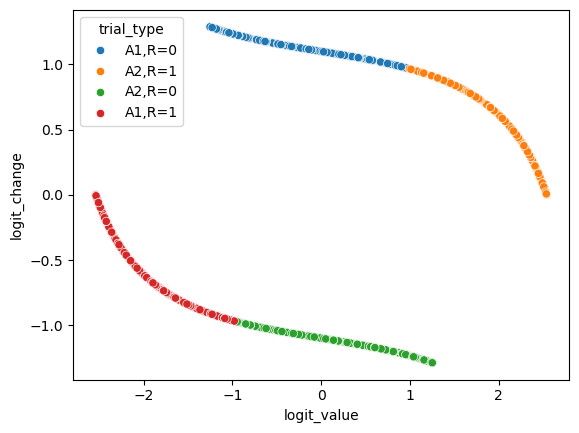

In [12]:
#Here we've got code to run all inner loops in parallel,  
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='trial_type')
outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 10,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-5],
                                                 'energy_lambdas':[1.0,1e-1,1e-2],
                                                 'hebbian_lambdas':[0.0],
                                                 'covariance_lambdas':[0.0]} )
print([d['val_loss'] for d in outer_results['inner_results']])


In [15]:
!squeue -u cburns

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           2902577       cpu     bash   cburns  R    2:49:22      1 enc2-node2


In [ ]:
reload(nested_jobs)
# for organising training of models, we aggregate an 'info_df', so we can keep track of paths and later also completion.
# this 'info_df' later becomes a scaffold pandas dataframe for analyses.

#see nested_jobs
test_df = nested_jobs.get_test_info_df()

test_df

#uncomment below to send jobs to HPC
test_df = nested_jobs.run_training(overwrite=True, test= True)